In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

In [2]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7152314/sum_cevns_fullphys_spectrum.root")
tree = file["Primary"]
tree2 = file["PrimaryPhononTracks"]
tree3 = file["SecondaryPhononTracks"]

df = tree.arrays(library="pd")
df2 = tree2.arrays(library="pd")
df3 = tree3.arrays(library="pd")

file_mono = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7152312/sum_cevns_full_mono.root")
tree_mono = file_mono["Primary"]
tree2_mono = file_mono["PrimaryPhononTracks"]
tree3_mono = file_mono["SecondaryPhononTracks"]

df_mono = tree_mono.arrays(library="pd")
df2_mono = tree2_mono.arrays(library="pd")
df3_mono = tree3_mono.arrays(library="pd")

#print((df2_mono['EventID']).value_counts().get(1,0))
#print((df2_mono['EventID']).value_counts().get(4,0))
#print((df2_mono['EventID']).value_counts().get(6,0))

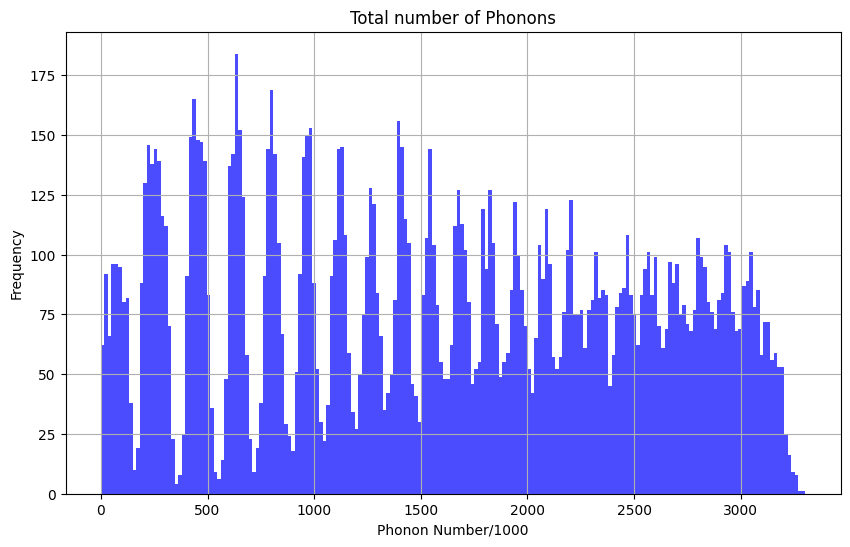

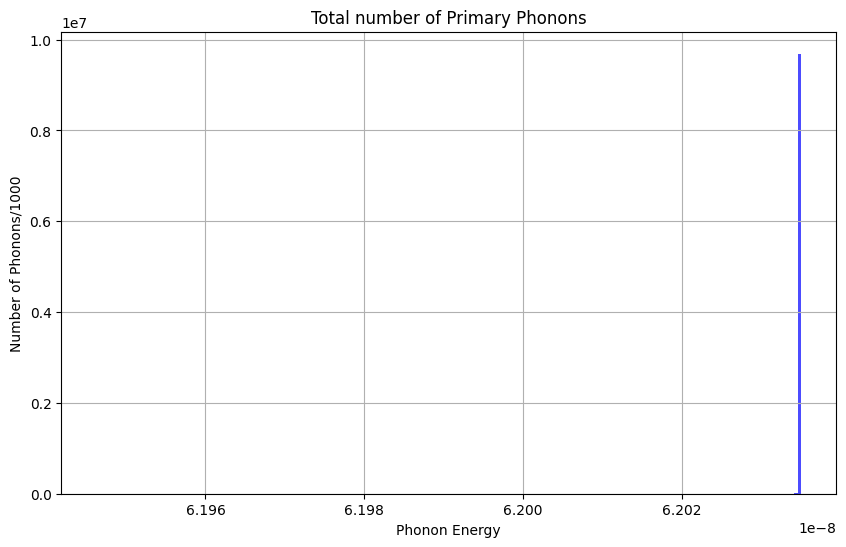

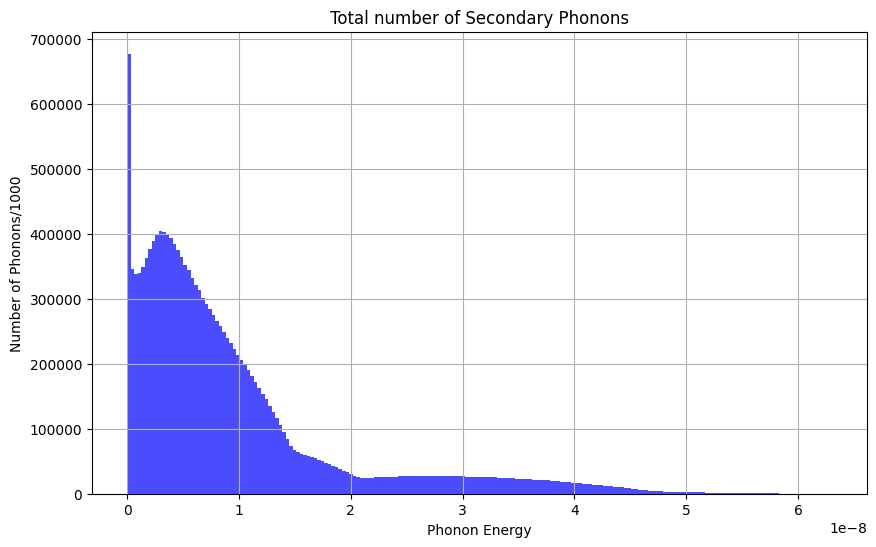

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(df['totalPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Phonons')
plt.xlabel('Phonon Number/1000')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("CEvNS_noscatt_phonon_number_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_primary_phonon_energy_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_phonon_energy_spectrum.pdf")
plt.show()

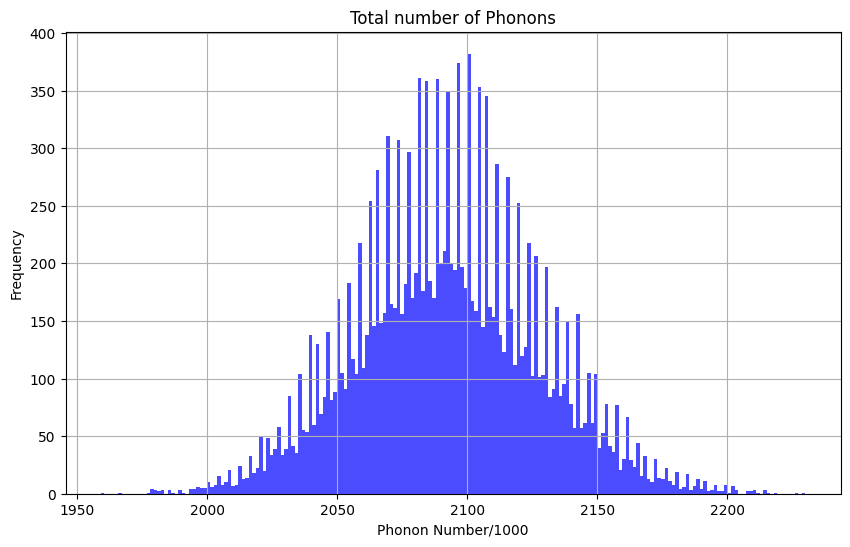

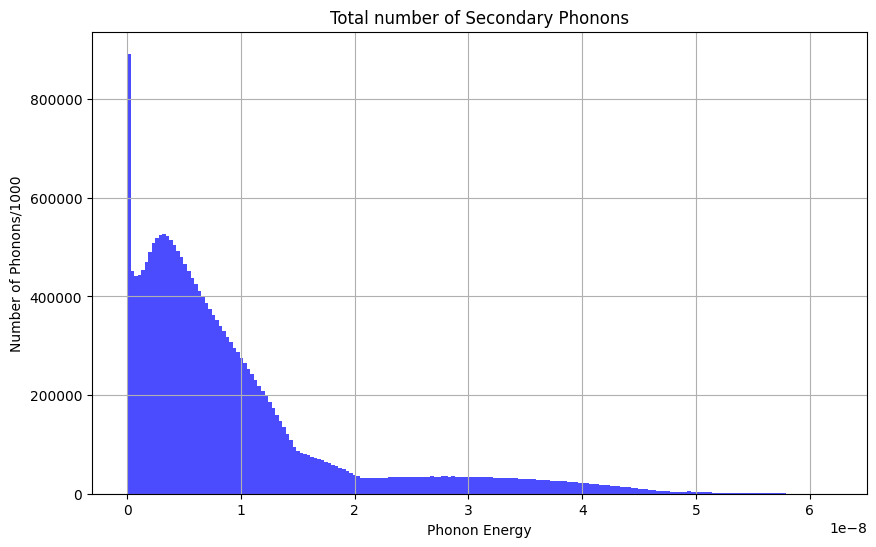

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(df_mono['totalPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Phonons')
plt.xlabel('Phonon Number/1000')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("CEvNS_noscatt_phonon_number_mono.pdf")
plt.show()
'''
plt.figure(figsize=(10, 6))
plt.hist(df2_mono['StartEnergy'], color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_primary_phonon_energy_mono.pdf")
plt.show()
'''
plt.figure(figsize=(10, 6))
plt.hist(df3_mono['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_mono.pdf")
plt.show()

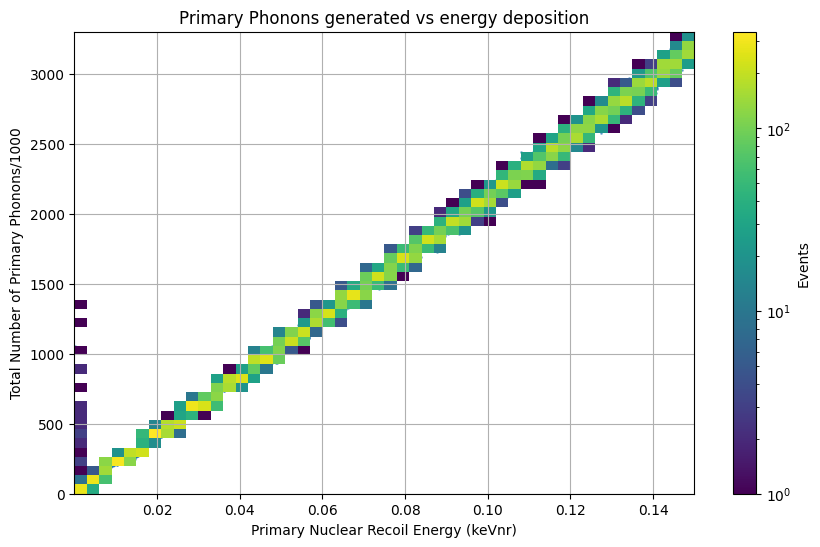

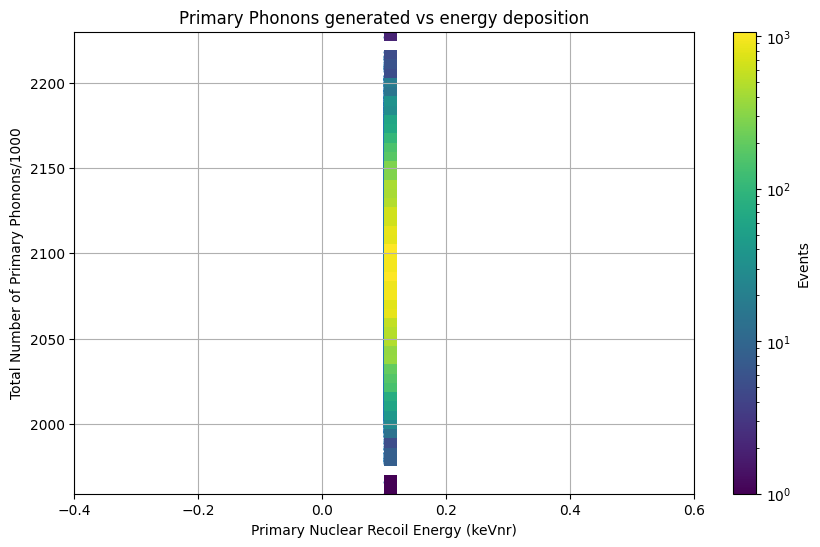

In [5]:
heatmap, xedges, yedges = np.histogram2d(df['PrimaryEnergy'], df['totalPhonons'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df['PrimaryEnergy'], df['totalPhonons'], alpha=0.5, s=1)
plt.title('Primary Phonons generated vs energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Total Number of Primary Phonons/1000')
plt.grid()
#plt.savefig("CEvNS_noscatt_phonons_vs_nredep_spectrum.pdf")
plt.show()

heatmap, xedges, yedges = np.histogram2d(df_mono['PrimaryEnergy'], df_mono['totalPhonons'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_mono['PrimaryEnergy'], df_mono['totalPhonons'], alpha=0.5, s=1)
plt.title('Primary Phonons generated vs energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Total Number of Primary Phonons/1000')
plt.grid()
#plt.savefig("CEvNS_noscatt_phonons_vs_nredep_mono.pdf")
plt.show()

In [6]:
from math import *
df2["momentum_mag"] = df2["StartMomX"]**2 + df2["StartMomY"]**2 + df2["StartMomZ"]**2
df2["mom_dir_x"] = df2["StartMomX"]/df2["momentum_mag"]**(1/2)
df2["mom_dir_y"] = df2["StartMomY"]/df2["momentum_mag"]**(1/2)
df2["mom_dir_z"] = df2["StartMomZ"]/df2["momentum_mag"]**(1/2)

df2_mono["momentum_mag"] = df2_mono["StartMomX"]**2 + df2_mono["StartMomY"]**2 + df2_mono["StartMomZ"]**2
df2_mono["mom_dir_x"] = df2_mono["StartMomX"]/df2_mono["momentum_mag"]**(1/2)
df2_mono["mom_dir_y"] = df2_mono["StartMomY"]/df2_mono["momentum_mag"]**(1/2)
df2_mono["mom_dir_z"] = df2_mono["StartMomZ"]/df2_mono["momentum_mag"]**(1/2)

df3["momentum_mag"] = df3["StartMomX"]**2 + df3["StartMomY"]**2 + df3["StartMomZ"]**2
df3["mom_dir_x"] = df3["StartMomX"]/df3["momentum_mag"]**(1/2)
df3["mom_dir_y"] = df3["StartMomY"]/df3["momentum_mag"]**(1/2)
df3["mom_dir_z"] = df3["StartMomZ"]/df3["momentum_mag"]**(1/2)

df3_mono["momentum_mag"] = df3_mono["StartMomX"]**2 + df3_mono["StartMomY"]**2 + df3_mono["StartMomZ"]**2
df3_mono["mom_dir_x"] = df3_mono["StartMomX"]/df3_mono["momentum_mag"]**(1/2)
df3_mono["mom_dir_y"] = df3_mono["StartMomY"]/df3_mono["momentum_mag"]**(1/2)
df3_mono["mom_dir_z"] = df3_mono["StartMomZ"]/df3_mono["momentum_mag"]**(1/2)

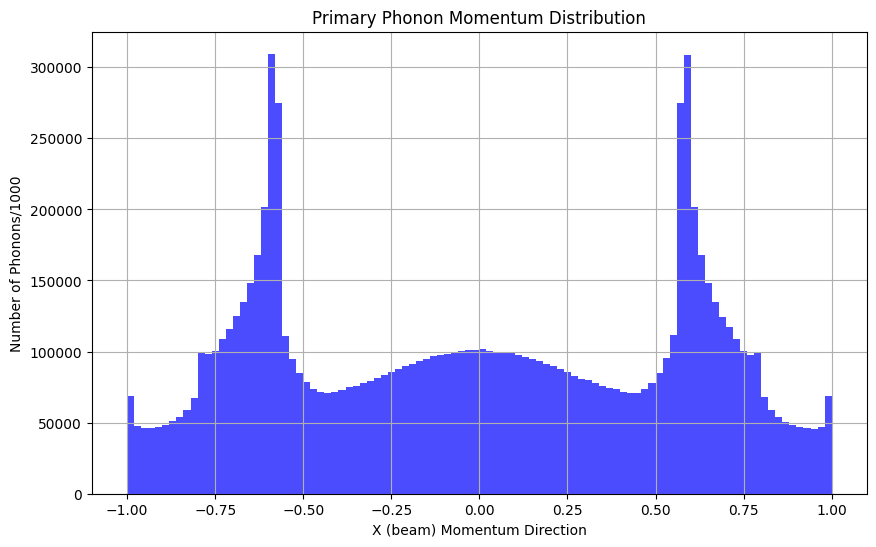

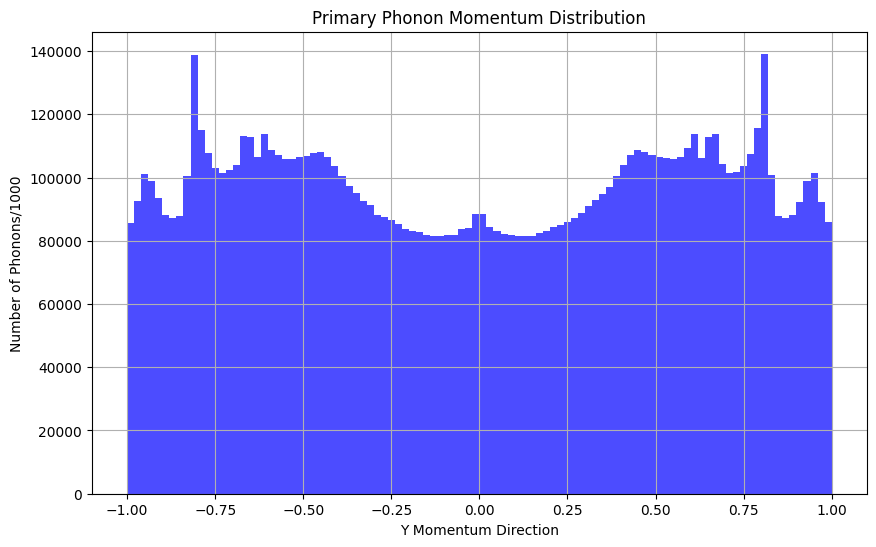

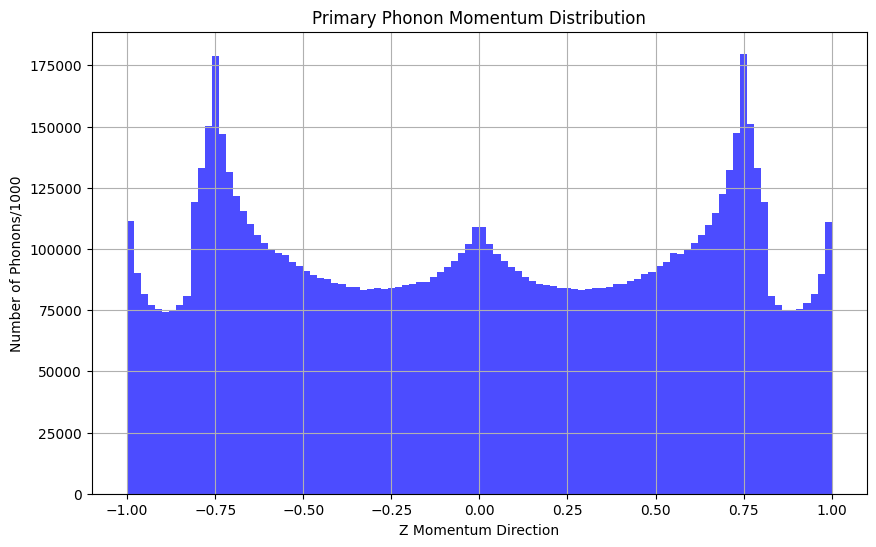

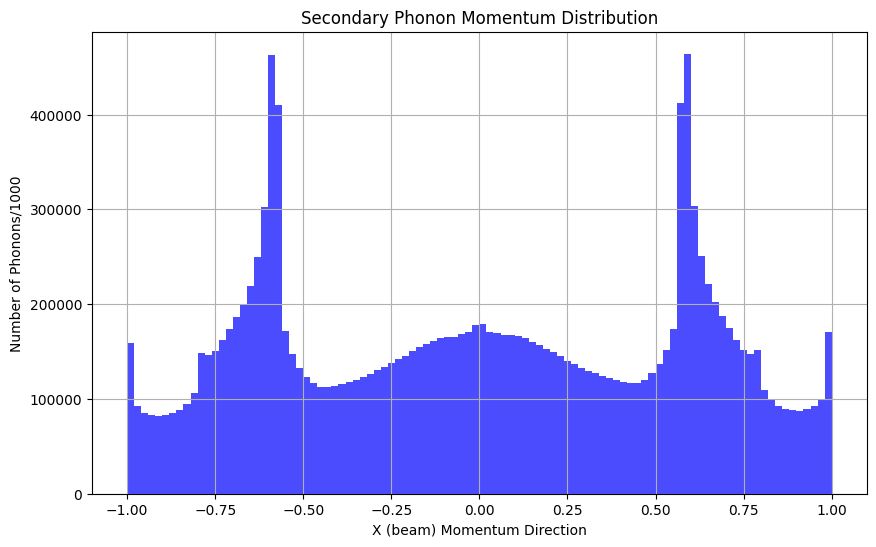

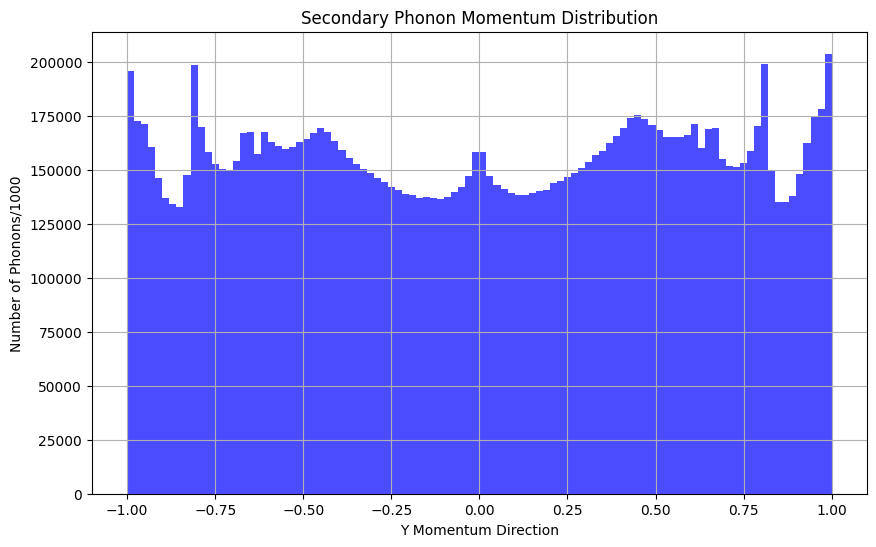

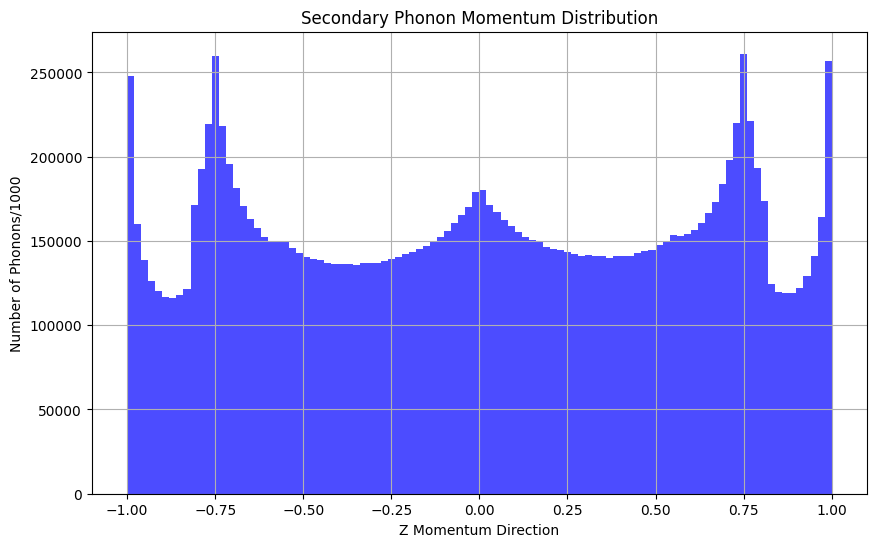

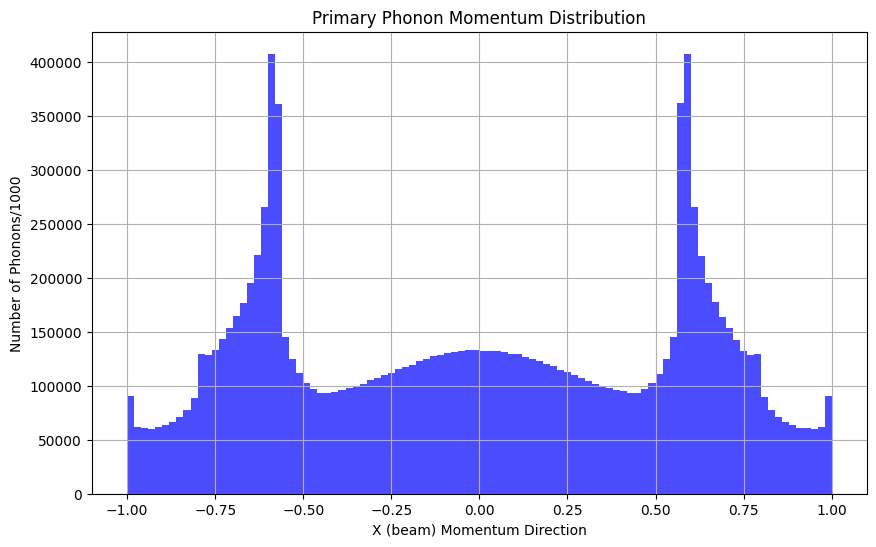

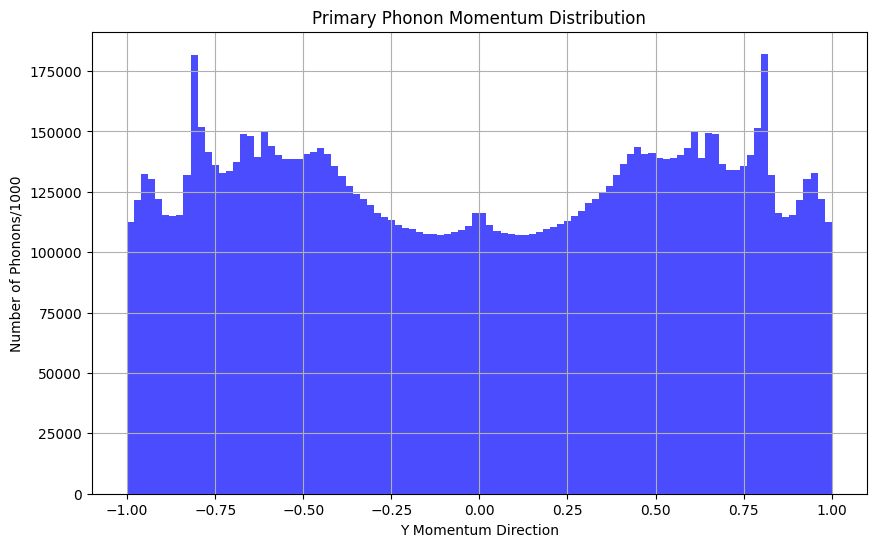

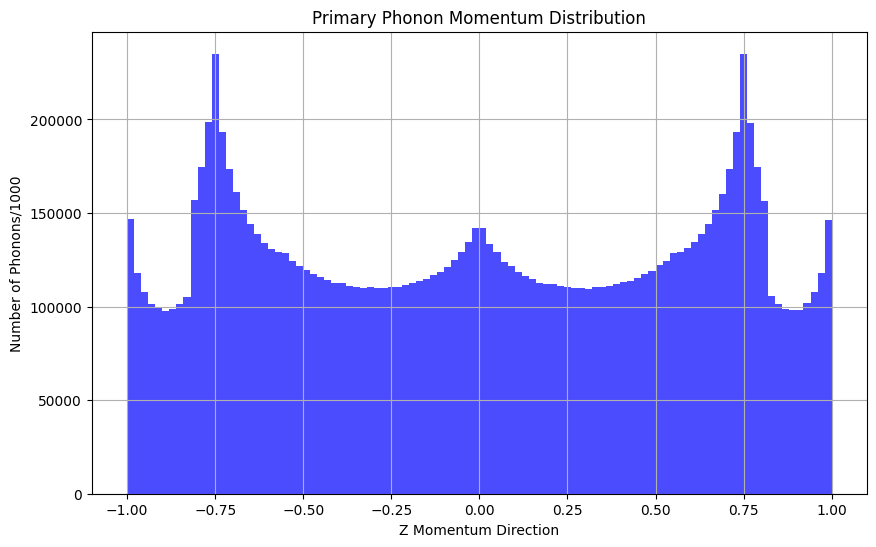

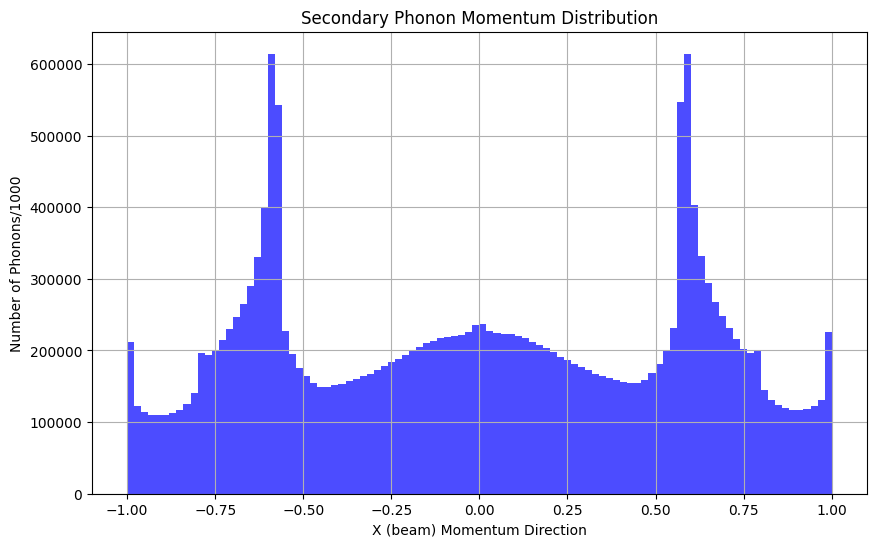

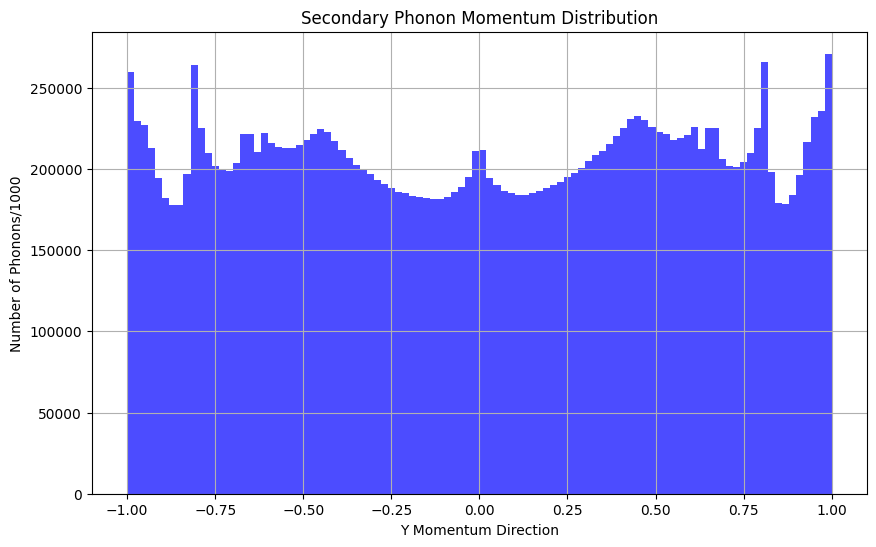

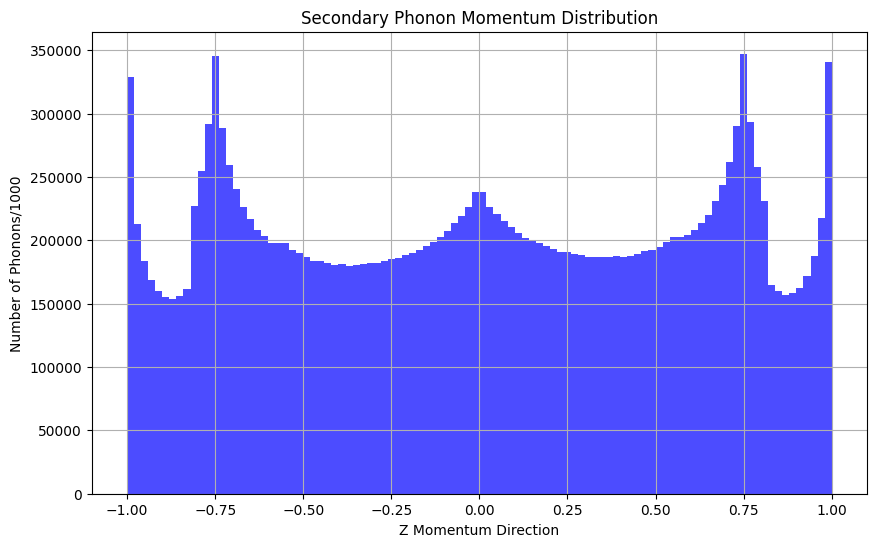

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_primary_phonon_momentumdirx_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_phonon_momentumdiry_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_primary_phonon_momentumdirz_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_phonon_momentumdirx_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_phonon_momentumdiry_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_phonon_momentumdirz_spectrum.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_primary_phonon_momentumdirx_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_primary_phonon_momentumdiry_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_primary_phonon_momentumdirz_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_phonon_momentumdirx_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_phonon_momentumdiry_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_noscatt_secondary_phonon_momentumdirz_mono.pdf")
plt.show()